# Weather Analysis

In [7]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("/home/jawad/my_jupyter_env/Data_Science_Projects/Urban-Road-Safety-Near-Miss-Analysis/urban_near_miss_dataset_12000.csv")

In [9]:
df.head()

,Record_ID,City,Day_of_Week,Hour,Weather,Traffic_Level,Vehicle_Type,Road_Type,Speed_Limit_kmh,Average_Speed_kmh,Pedestrian_Count,Visibility_Percent,Near_Miss_Score,Incident
0,1,Peshawar,Thursday,6,Cloudy,Medium,Motorcycle,Main Road,60,51.7,11,82.3,40.2,0
1,2,Karachi,Friday,19,Clear,Medium,Bus,Residential,50,51.8,10,91.1,31.6,0
2,3,Rawalpindi,Friday,14,Clear,Medium,Rickshaw,Residential,50,74.7,11,82.2,44.8,0
3,4,Peshawar,Sunday,10,Rain,High,Car,Main Road,60,39.4,7,74.0,35.6,0
4,5,Rawalpindi,Saturday,7,Rain,Severe,Rickshaw,Highway,100,62.5,8,97.3,57.1,1


# wheather analysis

In [10]:
# how many observation occured in each wheather condition ?
wheather_cond = df["Weather"].value_counts()
print("wheather_cond : \n",wheather_cond)
print("__"*30)

# which weather condition has the most incident ?
most_incident = df.groupby("Weather")["Incident"].sum().idxmax()
print("\n\nWeather on which most incident occured : ",most_incident)
print("__"*30)


# which weather has the high most near miss score ?
weather_high_miss_score = df.groupby("Weather")["Near_Miss_Score"].mean().idxmax()
print("Weather high Near Miss Score : ",weather_high_miss_score)
print("__"*30)


# Does rain apper to incres risk ?
rain_appear = df["Weather"] == "Rain"
rain_appear_inc_risk = df.groupby(rain_appear)["Incident"].sum()
print("\n\nrain vs non rain risk observation :\n",rain_appear_inc_risk)
print("__"*30)


# Does fog appear to increse risk ?
fog_appear = df["Weather"] == "Fog"
fog_summary = df.groupby(fog_appear)["Incident"].sum()
print("\n\nwheater is fog : ",fog_summary)
print("__"*30)



# Compare average visability for each weather condition ?
compare_avg_vis = df.groupby("Weather")["Visibility_Percent"].mean()
print("\n\ncomparing average visiability of weather : ",compare_avg_vis)
print("__"*30)


wheather_cond : 
 Weather
Clear     5939
Cloudy    2403
Rain      1485
Dust      1199
Fog        974
Name: count, dtype: int64
____________________________________________________________


Weather on which most incident occured :  Clear
____________________________________________________________
Weather high Near Miss Score :  Fog
____________________________________________________________


rain vs non rain risk observation :
 Weather
False    1703
True      315
Name: Incident, dtype: int64
____________________________________________________________


wheater is fog :  Weather
False    1704
True      314
Name: Incident, dtype: int64
____________________________________________________________


comparing average visiability of weather :  Weather
Clear     89.698131
Cloudy    89.439534
Dust      65.116931
Fog       45.011191
Rain      78.338519
Name: Visibility_Percent, dtype: float64
____________________________________________________________


# Weather Vs Incident count 

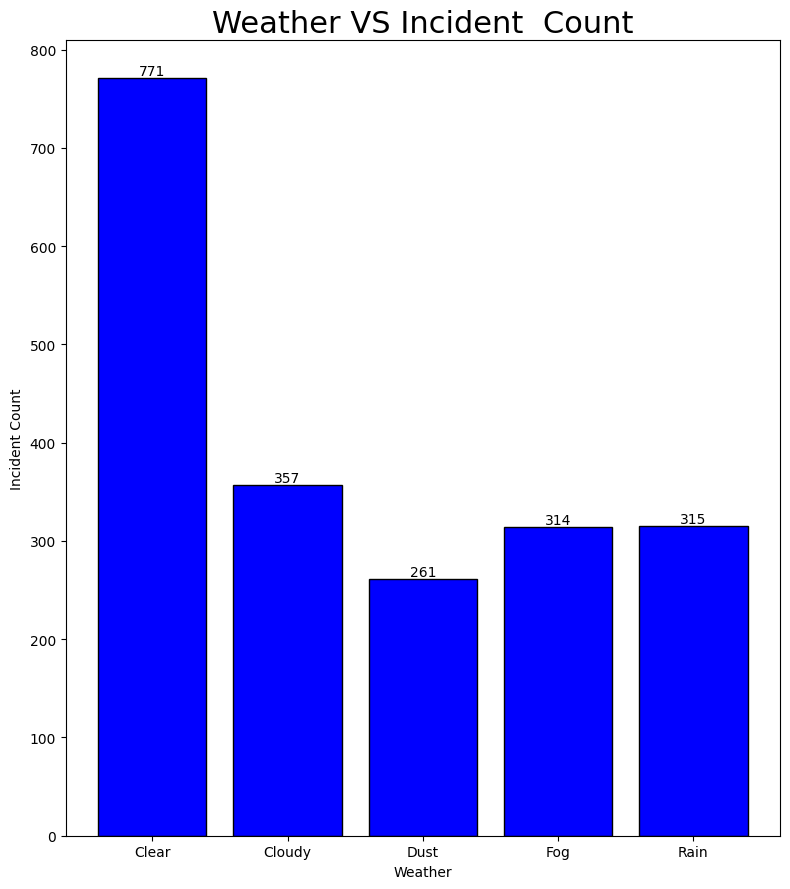

In [11]:
weather_Vs_incid_count = df.groupby("Weather")["Incident"].sum()
plt.figure(figsize=(8,9))
bar = plt.bar(weather_Vs_incid_count.index,weather_Vs_incid_count.values,color = "blue",edgecolor="Black")
plt.bar_label(bar)
plt.title("Weather VS Incident  Count",fontsize = 22)
plt.xlabel("Weather")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.savefig("weather_Vs_incid_count.png",dpi=300,bbox_inches = "tight")
plt.show()